In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
eda = pd.read_excel('../Data/CBDI3 All Evals for NSS.xlsx')
eda.head()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Code 1,Code 2,Code 3,Code 4,Code 5,Code 6,Code 7,Code 8,Code 9,Code 10
0,44879,F,2022-09-27,Southwest,contract 3,BDI-3 Eligibility Evaluation,7.0,85.0,16,77-97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,47795,F,2020-12-23,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,16.0,88.0,21,82-96,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,54340,M,2021-06-22,First Tennessee,contract 1,BDI-3 Eligibility Evaluation,8.0,90.0,25,81-101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,54344,F,2022-03-07,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,13.0,115.0,84,103-123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,54515,M,2021-11-04,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,5.0,75.0,5,68-88,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Cleaning & Exploration

In [3]:
#dropping columns
eda = eda.drop_duplicates().drop(columns = ['Code 1','Code 2','Code 3','Code 4','Code 5','Code 6','Code 7','Code 8','Code 9','Code 10'])

In [4]:
eda_program_table = eda['Program Label'].value_counts().reset_index()
eda_program_table

,Program Label,count
0,BDI-3 Eligibility Evaluation,12392
1,BDI-3 Annual Evaluation,6905
2,BDI-3 Milestone or Exit Evaluation,203


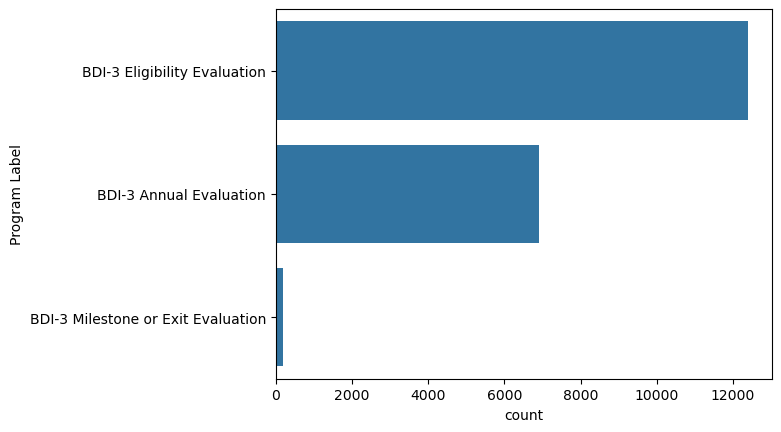

In [5]:
sns.barplot(data=eda_program_table, y="Program Label", x="count")
plt.show()

In [6]:
# Clean Adaptive RDI
eda['Adaptive RDI'] = eda['Adaptive RDI'].astype(str)

In [7]:
eda_rdi = eda.loc[eda['Adaptive RDI'].str.contains('-', na=False)]
eda_rdi['Adaptive RDI']

4        1990-09-01 00:00:00
16       1990-01-01 00:00:00
23       1990-10-01 00:00:00
33       1990-12-01 00:00:00
36       1990-09-01 00:00:00
                ...         
23923    1990-02-01 00:00:00
23924    1990-07-01 00:00:00
23925    1990-09-01 00:00:00
23935    1990-03-01 00:00:00
23938    1990-04-01 00:00:00
Name: Adaptive RDI, Length: 1924, dtype: object

In [8]:
eda['Adaptive RDI'] = eda['Adaptive RDI'].replace('1990-01-01 00:00:00', '9/90').replace('1990-02-01 00:00:00', '2/90').replace('1990-03-01 00:00:00', '3/90').replace('1990-04-01 00:00:00', '4/90').replace('1990-05-01 00:00:00', '5/90').replace('1990-06-01 00:00:00', '6/90').replace('1990-07-01 00:00:00', '7/90').replace('1990-08-01 00:00:00', '8/90').replace('1990-09-01 00:00:00', '9/90').replace('1990-10-01 00:00:00', '10/90').replace('1990-11-01 00:00:00', '11/90').replace('1990-12-01 00:00:00', '12/90')

In [9]:
eda['Adaptive RDI']

0        39/90
1        79/90
2        77/90
3        99/90
4         9/90
         ...  
23942    99/90
23943    96/90
23944    92/90
23945    66/90
23946    94/90
Name: Adaptive RDI, Length: 19500, dtype: object

# Q1 In which domains (and sub-domains) are children performing highest and lowest?

In [10]:
Domains = ['BDI-3 Total','Adaptive', 'Social-Emotional','Communication','Motor','Cognitive']

for dom in Domains:
    eda[f'{dom} Percentile Rank'] = eda[f'{dom} Percentile Rank'].astype('string')


In [11]:
eda[['BDI-3 Total Percentile Rank','Adaptive Percentile Rank','Social-Emotional Percentile Rank','Communication Percentile Rank','Motor Percentile Rank',
'Cognitive Percentile Rank']].dtypes


BDI-3 Total Percentile Rank         string[python]
Adaptive Percentile Rank            string[python]
Social-Emotional Percentile Rank    string[python]
Communication Percentile Rank       string[python]
Motor Percentile Rank               string[python]
Cognitive Percentile Rank           string[python]
dtype: object

In [12]:
Domains = ['BDI-3 Total','Adaptive', 'Social-Emotional','Communication','Motor','Cognitive']

for dom in Domains:
    eda[f'{dom} Percentile Rank'] = eda[f'{dom} Percentile Rank'].str.replace('<','').str.replace('>','')

In [13]:
eda[['BDI-3 Total Percentile Rank','Adaptive Percentile Rank','Social-Emotional Percentile Rank','Communication Percentile Rank','Motor Percentile Rank',
'Cognitive Percentile Rank']].sort_values(by = "Social-Emotional Percentile Rank", ascending = False)

,BDI-3 Total Percentile Rank,Adaptive Percentile Rank,Social-Emotional Percentile Rank,Communication Percentile Rank,Motor Percentile Rank,Cognitive Percentile Rank
8767,96,95,99.9,73,95,42
21101,99.7,84,99.9,99,99,91
19953,88,25,99.9,34,84,87
18943,99,75,99.9,95,99,87
23318,99,99,99.9,84,84,94
...,...,...,...,...,...,...
21803,<NA>,63,<NA>,<NA>,<NA>,<NA>
21899,<NA>,0.1,<NA>,<NA>,<NA>,<NA>
22503,<NA>,21,<NA>,2,45,9
22565,<NA>,63,<NA>,<NA>,<NA>,<NA>


In [14]:
Domains = ['BDI-3 Total','Adaptive', 'Social-Emotional','Communication','Motor','Cognitive']

for dom in Domains:
    eda[f'{dom} Percentile Rank'] = eda[f'{dom} Percentile Rank'].astype('float')

In [15]:
eda[['BDI-3 Total Percentile Rank','Adaptive Percentile Rank','Social-Emotional Percentile Rank','Communication Percentile Rank','Motor Percentile Rank',
'Cognitive Percentile Rank']].dtypes

BDI-3 Total Percentile Rank         float64
Adaptive Percentile Rank            float64
Social-Emotional Percentile Rank    float64
Communication Percentile Rank       float64
Motor Percentile Rank               float64
Cognitive Percentile Rank           float64
dtype: object

In [16]:
pr_name =[]
pr_value = []

Domains = ['BDI-3 Total','Adaptive', 'Social-Emotional','Communication','Motor','Cognitive']
for dom in Domains:
    print(f'{dom} AVG PR = {eda[f"{dom} Percentile Rank"].mean()}')
    pr_name.append(f'{dom} AVG PR')
    pr_value.append(eda[f"{dom} Percentile Rank"].mean())


BDI-3 Total AVG PR = 29.780918582523274
Adaptive AVG PR = 29.912891807315447
Social-Emotional AVG PR = 40.689010932607914
Communication AVG PR = 21.57764651497252
Motor AVG PR = 41.667104925273485
Cognitive AVG PR = 31.452892561983475


In [17]:
domain_pr = pd.DataFrame({"pr_name":pr_name, "pr_value":pr_value})

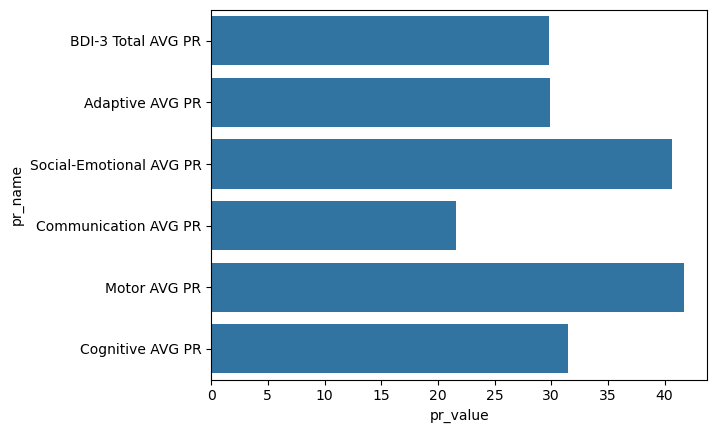

In [18]:
sns.barplot(data=domain_pr, y="pr_name", x="pr_value")

plt.show()

# Q2 - What is the pattern of children's scores? Do individual children tend to perform similarly across all domains or are there differences from domain to domain? Are these patterns similar for all children?

In [19]:
eda_trim = eda[['Child ID','Gender','Date of Birth','Program Label','Location - Sub Level 1','contract number','Adaptive Percentile Rank','Social-Emotional Percentile Rank','Communication Percentile Rank','Motor Percentile Rank','BDI-3 Total Percentile Rank','Cognitive Percentile Rank','Adaptive-Self Care Date of Testing'
]]
eda_trim

,Child ID,Gender,Date of Birth,Program Label,Location - Sub Level 1,contract number,Adaptive Percentile Rank,Social-Emotional Percentile Rank,Communication Percentile Rank,Motor Percentile Rank,BDI-3 Total Percentile Rank,Cognitive Percentile Rank,Adaptive-Self Care Date of Testing
0,44879,F,2022-09-27,BDI-3 Eligibility Evaluation,Southwest,contract 3,16.0,96.0,27.0,21.0,47.0,50.0,2023-06-23
1,47795,F,2020-12-23,BDI-3 Eligibility Evaluation,Greater Nashville,contract 2,21.0,61.0,42.0,55.0,47.0,50.0,2023-03-21
2,54340,M,2021-06-22,BDI-3 Eligibility Evaluation,First Tennessee,contract 1,25.0,27.0,12.0,73.0,23.0,13.0,2023-04-06
3,54344,F,2022-03-07,BDI-3 Eligibility Evaluation,Southeast Tennessee,contract 1,84.0,58.0,21.0,27.0,53.0,81.0,2023-02-23
4,54515,M,2021-11-04,BDI-3 Eligibility Evaluation,Memphis Delta,contract 3,5.0,4.0,2.0,4.0,3.0,42.0,2023-02-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,SP03287,F,2023-09-25,BDI-3 Eligibility Evaluation,Memphis Delta,contract 3,84.0,84.0,79.0,88.0,90.0,81.0,2023-11-15
23943,SP03288,F,2021-05-18,BDI-3 Eligibility Evaluation,South Central,contract 2,84.0,86.0,79.0,87.0,90.0,93.0,2023-11-13
23944,SP03289,F,2021-10-31,BDI-3 Eligibility Evaluation,South Central,contract 2,58.0,55.0,0.1,61.0,34.0,45.0,2023-11-14
23945,SP03290,M,2020-03-25,BDI-3 Annual Evaluation,Memphis Delta,contract 3,21.0,25.0,5.0,50.0,21.0,21.0,2023-10-26


In [20]:
eda_trim_filter = eda_trim.sort_values('Adaptive-Self Care Date of Testing').drop_duplicates(subset=['Child ID'],keep='first')

In [21]:
eda_trim_filter['Child ID'] = eda_trim_filter['Child ID'].astype('string').str.strip()
eda_trim_filter['Child ID'].dtype

string[python]

In [22]:
eda_trim_filter.sort_values(by='Child ID')

,Child ID,Gender,Date of Birth,Program Label,Location - Sub Level 1,contract number,Adaptive Percentile Rank,Social-Emotional Percentile Rank,Communication Percentile Rank,Motor Percentile Rank,BDI-3 Total Percentile Rank,Cognitive Percentile Rank,Adaptive-Self Care Date of Testing
20357,11111111111,F,2023-02-27,BDI-3 Eligibility Evaluation,Southeast Tennessee,contract 1,25.0,88.0,50.0,34.0,58.0,58.0,2023-09-14
20354,35542520,M,2020-03-07,BDI-3 Annual Evaluation,Greater Nashville,contract 2,88.0,50.0,42.0,NaN,NaN,45.0,2023-06-12
19,404042,M,2020-03-17,BDI-3 Annual Evaluation,Upper Cumberland,contract 2,0.1,0.1,0.1,0.1,0.1,0.1,2023-03-09
21,419577,F,2021-12-21,BDI-3 Annual Evaluation,East Tennessee,contract 1,37.0,16.0,27.0,34.0,30.0,68.0,2023-03-22
23,436346,F,2022-09-01,BDI-3 Eligibility Evaluation,South Central,contract 2,5.0,50.0,34.0,50.0,42.0,75.0,2023-02-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23942,SP03287,F,2023-09-25,BDI-3 Eligibility Evaluation,Memphis Delta,contract 3,84.0,84.0,79.0,88.0,90.0,81.0,2023-11-15
23943,SP03288,F,2021-05-18,BDI-3 Eligibility Evaluation,South Central,contract 2,84.0,86.0,79.0,87.0,90.0,93.0,2023-11-13
23944,SP03289,F,2021-10-31,BDI-3 Eligibility Evaluation,South Central,contract 2,58.0,55.0,0.1,61.0,34.0,45.0,2023-11-14
23945,SP03290,M,2020-03-25,BDI-3 Annual Evaluation,Memphis Delta,contract 3,21.0,25.0,5.0,50.0,21.0,21.0,2023-10-26


## learning np.select

In [23]:
#2
conditions = [
    (eda_trim_filter['Adaptive Percentile Rank']>=eda_trim_filter['Social-Emotional Percentile Rank']) & (eda_trim_filter['Adaptive Percentile Rank']>=eda_trim_filter['Communication Percentile Rank'])&(eda_trim_filter['Adaptive Percentile Rank']>=eda_trim_filter['Motor Percentile Rank'])&(eda_trim_filter['Adaptive Percentile Rank']>=eda_trim_filter['Cognitive Percentile Rank']),
    (eda_trim_filter['Social-Emotional Percentile Rank']>eda_trim_filter['Adaptive Percentile Rank']) & (eda_trim_filter['Social-Emotional Percentile Rank']>eda_trim_filter['Communication Percentile Rank'])&(eda_trim_filter['Social-Emotional Percentile Rank']>eda_trim_filter['Motor Percentile Rank'])&(eda_trim_filter['Social-Emotional Percentile Rank']>eda_trim_filter['Cognitive Percentile Rank']),
    (eda_trim_filter['Communication Percentile Rank']>eda_trim_filter['Social-Emotional Percentile Rank']) & (eda_trim_filter['Communication Percentile Rank']>eda_trim_filter['Adaptive Percentile Rank'])&(eda_trim_filter['Communication Percentile Rank']>eda_trim_filter['Motor Percentile Rank'])&(eda_trim_filter['Communication Percentile Rank']>eda_trim_filter['Cognitive Percentile Rank']),
    (eda_trim_filter['Motor Percentile Rank']>eda_trim_filter['Social-Emotional Percentile Rank']) & (eda_trim_filter['Motor Percentile Rank']>eda_trim_filter['Communication Percentile Rank'])&(eda_trim_filter['Motor Percentile Rank']>eda_trim_filter['Adaptive Percentile Rank'])&(eda_trim_filter['Motor Percentile Rank']>eda_trim_filter['Cognitive Percentile Rank']),
    (eda_trim_filter['Cognitive Percentile Rank']>eda_trim_filter['Social-Emotional Percentile Rank']) &(eda_trim_filter['Cognitive Percentile Rank']>eda_trim_filter['Communication Percentile Rank'])&(eda_trim_filter['Cognitive Percentile Rank']>eda_trim_filter['Motor Percentile Rank'])&(eda_trim_filter['Cognitive Percentile Rank']>eda_trim_filter['Adaptive Percentile Rank'])

]

choices = ['Adaptive','Social Emotional','Communication','Motor','Cognitive']

eda_trim_filter['top'] = np.select(
    conditions, choices, default='same or NaN')
    

In [24]:
eda_trim_filter.sort_values(by="Communication Percentile Rank", ascending = False)

,Child ID,Gender,Date of Birth,Program Label,Location - Sub Level 1,contract number,Adaptive Percentile Rank,Social-Emotional Percentile Rank,Communication Percentile Rank,Motor Percentile Rank,BDI-3 Total Percentile Rank,Cognitive Percentile Rank,Adaptive-Self Care Date of Testing,top
21730,SP01075,M,2021-10-21,BDI-3 Annual Evaluation,Upper Cumberland,contract 2,99.9,92.0,99.9,99.9,99.9,99.0,2023-05-08,Adaptive
2745,510287,F,2021-08-06,BDI-3 Annual Evaluation,Memphis Delta,contract 3,84.0,95.0,99.9,99.0,99.0,97.0,2023-10-16,Communication
2746,510290,M,2021-08-06,BDI-3 Annual Evaluation,Memphis Delta,contract 3,21.0,82.0,99.9,99.0,95.0,95.0,2023-10-16,Communication
2576,509228,M,2021-05-12,BDI-3 Annual Evaluation,Southwest,contract 3,98.0,98.0,99.9,96.0,98.0,82.0,2023-06-12,Communication
21070,SP00415,M,2023-02-09,BDI-3 Eligibility Evaluation,Upper Cumberland,contract 2,84.0,99.0,99.9,92.0,99.7,99.0,2023-04-04,Communication
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22111,SP01456,F,2021-06-20,BDI-3 Annual Evaluation,East Tennessee,contract 1,50.0,34.0,NaN,81.0,NaN,45.0,2023-08-28,same or NaN
23642,SP02987,M,2023-01-01,BDI-3 Eligibility Evaluation,First Tennessee,contract 1,84.0,58.0,NaN,16.0,NaN,19.0,2023-09-18,same or NaN
19259,564105,F,2023-09-14,BDI-3 Eligibility Evaluation,Upper Cumberland,contract 2,91.0,34.0,NaN,42.0,NaN,9.0,2023-10-02,same or NaN
7441,531583,F,2022-06-17,BDI-3 Annual Evaluation,Greater Nashville,contract 2,63.0,99.0,NaN,92.0,NaN,68.0,2023-10-06,same or NaN


In [25]:
top_domains = eda_trim_filter.groupby('top')['Child ID'].count().reset_index()
    #.sort_values(by = "BDI-3 Total-Avg PR", ascending = True)
top_domains

,top,Child ID
0,Adaptive,2791
1,Cognitive,2113
2,Communication,994
3,Motor,6633
4,Social Emotional,5450
5,same or NaN,1022


<Axes: xlabel='Child ID', ylabel='top'>

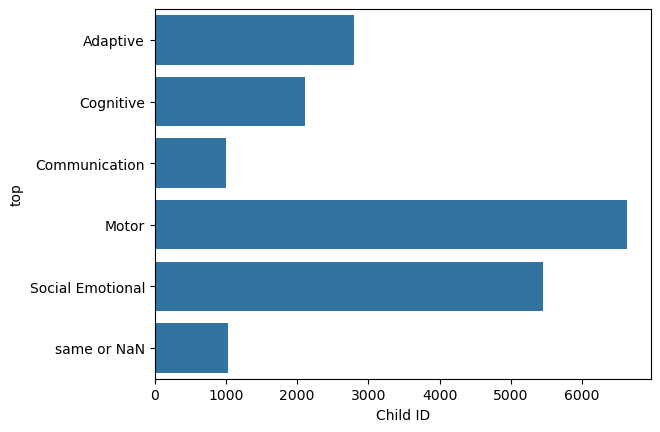

In [26]:
sns.set_color_codes("pastel")
sns.barplot(data = top_domains, y="top", x="Child ID")

## Learning def and apply

In [27]:
def classify(Adaptive):
    if Adaptive > 50:
        return 'Above Avg'
    elif Adaptive == 50:
        return 'Avg'
    else:
        return 'Below Avg'

eda_trim_filter['Adaptive'] = eda_trim_filter['Adaptive Percentile Rank'].apply(classify)
eda_trim_filter

,Child ID,Gender,Date of Birth,Program Label,Location - Sub Level 1,contract number,Adaptive Percentile Rank,Social-Emotional Percentile Rank,Communication Percentile Rank,Motor Percentile Rank,BDI-3 Total Percentile Rank,Cognitive Percentile Rank,Adaptive-Self Care Date of Testing,top,Adaptive
10524,542205,M,2021-05-10,BDI-3 Eligibility Evaluation,Greater Nashville,contract 2,63.0,58.0,27.0,84.0,53.0,25.0,2022-12-08,Motor,Above Avg
460,489576,F,2020-07-08,BDI-3 Eligibility Evaluation,Greater Nashville,contract 2,0.1,30.0,1.0,10.0,4.0,5.0,2022-12-08,Social Emotional,Below Avg
10278,540677,M,2022-05-09,BDI-3 Eligibility Evaluation,Greater Nashville,contract 2,37.0,79.0,21.0,34.0,53.0,81.0,2022-12-08,Cognitive,Below Avg
10461,541881,F,2022-11-07,BDI-3 Eligibility Evaluation,Southwest,contract 3,37.0,12.0,42.0,73.0,32.0,25.0,2022-12-12,Motor,Below Avg
10444,541736,F,2021-07-12,BDI-3 Eligibility Evaluation,Southeast Tennessee,contract 1,63.0,73.0,73.0,42.0,77.0,94.0,2022-12-13,Cognitive,Above Avg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20044,566041,M,2023-04-11,BDI-3 Eligibility Evaluation,East Tennessee,contract 1,1.0,73.0,1.0,16.0,8.0,13.0,2023-11-15,Social Emotional,Below Avg
38,475907,M,2019-11-18,BDI-3 Annual Evaluation,Southeast Tennessee,contract 1,4.0,18.0,2.0,4.0,3.0,1.0,2023-11-15,Social Emotional,Below Avg
20275,566880,M,2022-04-29,BDI-3 Eligibility Evaluation,East Tennessee,contract 1,37.0,42.0,21.0,88.0,55.0,68.0,2023-11-15,Motor,Below Avg
20066,566116,M,2021-08-31,BDI-3 Eligibility Evaluation,South Central,contract 2,21.0,14.0,12.0,50.0,19.0,21.0,2023-11-15,Motor,Below Avg


In [3]:
def classify(Adaptive):
    if Adaptive > 50:
        'Above Avg'
    elif Adaptive == 50:
        'Avg'
    else:
        'Below Avg'

eda_trim_filter['Adaptive'] = eda_trim_filter['Adaptive Percentile Rank'].apply(classify)
eda_trim_filter

NameError: name 'eda_trim_filter' is not defined

# Q8 Is there any notable pattern of scoring by evaluator?


In [28]:
eda[['Motor-Fine Motor Examiner','Motor-Gross Motor Examiner','Adaptive-Self Care Examiner','Motor-Perceptual Motor Examiner','Cognitive-Attention and Memory Examiner','Adaptive-Personal Responsibility Examiner', 'Social Emotional-Peer Interaction Examiner','Cognitive-Perception and Concepts Examiner','Social Emotional-Adult Interaction Examiner','Communication-Receptive Communication Examiner','Cognitive-Reasoning / Academic Skills Examiner','Communication-Expressive Communication Examiner','Social Emotional-Self Concept / Social Role Examiner']]
eda_examiner = eda.rename(columns={'Motor-Fine Motor Examiner': 'Examiner'})

In [29]:
eda_examiner = eda_examiner.groupby('Examiner')[['BDI-3 Total Percentile Rank',
'Adaptive Percentile Rank','Social-Emotional Percentile Rank','Communication Percentile Rank','Motor Percentile Rank',
'Cognitive Percentile Rank']].mean()

eda_examiner = eda_examiner.reset_index()
eda_examiner = eda_examiner.rename(columns={'BDI-3 Total Percentile Rank': 'BDI-3 Total-Avg PR','Adaptive Percentile Rank':'Adaptive-Avg PR','Social-Emotional Percentile Rank': 'Social-Emotional-Avg PR','Communication Percentile Rank':'Communication-Avg PR','Motor Percentile Rank':'Motor-Avg PR',
'Cognitive Percentile Rank':'Cognitive-Avg PR'})


In [30]:
eda_examiner[['BDI-3 Total-Avg PR','Adaptive-Avg PR','Social-Emotional-Avg PR','Communication-Avg PR','Motor-Avg PR','Cognitive-Avg PR']].mean()

BDI-3 Total-Avg PR         29.685655
Adaptive-Avg PR            29.656889
Social-Emotional-Avg PR    41.890136
Communication-Avg PR       21.290685
Motor-Avg PR               40.962274
Cognitive-Avg PR           31.314795
dtype: float64

In [31]:
eda_examiner['Examiner'].nunique()

105

In [32]:
eda_exam_counts = eda['Motor-Fine Motor Examiner'].value_counts().reset_index()
eda_exam_counts

,Motor-Fine Motor Examiner,count
0,Kelly Brackney,430
1,Tracey Hardiman,412
2,Emily Williams,376
3,Kelly Bryan,373
4,Kathie Reuss,372
...,...,...
100,Amanda Harris,2
101,Karie Quick,2
102,Sara Turner,2
103,Kendra Inman,1


In [33]:
# Checking how many examiners are in each range of number of assessments given.
eda_exam_counts2 = eda_exam_counts.groupby(pd.cut(eda_exam_counts['count'], bins=8))['count'].count()
eda_exam_counts2

C:\Users\jlmow\AppData\Local\Temp\ipykernel_29040\2363282289.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_exam_counts2 = eda_exam_counts.groupby(pd.cut(eda_exam_counts['count'], bins=8))['count'].count()


count
(0.571, 54.625]      23
(54.625, 108.25]     11
(108.25, 161.875]    16
(161.875, 215.5]      6
(215.5, 269.125]     18
(269.125, 322.75]    15
(322.75, 376.375]    14
(376.375, 430.0]      2
Name: count, dtype: int64

In [34]:
eda_examiner['Examiner'].unique()

array(['Abby Spence', 'Alexis Linville', 'Alice Starnes',
       'Allison Coontz', 'Ally Simmons', 'Amanda Harris',
       'Amelia Ferguson', 'Amy Callender', 'Amy Ownby', 'Amy Waters',
       'Andrea Kilgore', 'Ann Ellis', 'Anna Koon', 'Aretha Blizzard',
       'Ariauna Buckingham', 'Arthur Hicks', 'Becca Farmer',
       'Becky Davidson', 'Bonnie Jones', 'Candice Padilla',
       'Carla Thomas', 'Carla Turner', 'Carrie Hutchison', 'Casey Mathis',
       'Catherine Pippin', 'Courtney Beaty', 'Dana Cook', 'Darla Tucker',
       'Dawn Reed', 'Dawne Pascoe', 'Dia Mimms', 'Dinorah Salinas',
       'Elisha Grubb', 'Elvira Castro de Silva', 'Emily Blevins',
       'Emily Williams', 'Gayla Bishop', 'Heather Jackson',
       'Heather Lyle', 'Heidi Wheeler', 'James Brown', 'Jamie Steward',
       'Janeth Cruz', 'Jasmine Jones', 'Jena Johnson', 'Jennifer Hodges',
       'Jennifer Terranera', 'Jennifer Tignor', 'Jennifer Vines',
       'Jenny Starcke', 'Jessica Caudle', 'Joanna Jones', 'Kacey Ser

In [35]:
eda_examiner_total = eda_examiner.groupby('Examiner')['BDI-3 Total-Avg PR'].mean().reset_index().sort_values(by = "BDI-3 Total-Avg PR", ascending = True)
eda_examiner_total

,Examiner,BDI-3 Total-Avg PR
93,Sara Turner,7.050000
44,Jena Johnson,10.393103
40,James Brown,15.568166
70,Laurie Brown,15.803600
30,Dia Mimms,15.918954
...,...,...
75,Melinda Morris,45.723774
12,Anna Koon,46.314286
29,Dawne Pascoe,47.333333
86,Patti Lyle,47.862105


<Axes: xlabel='Examiner', ylabel='BDI-3 Total-Avg PR'>

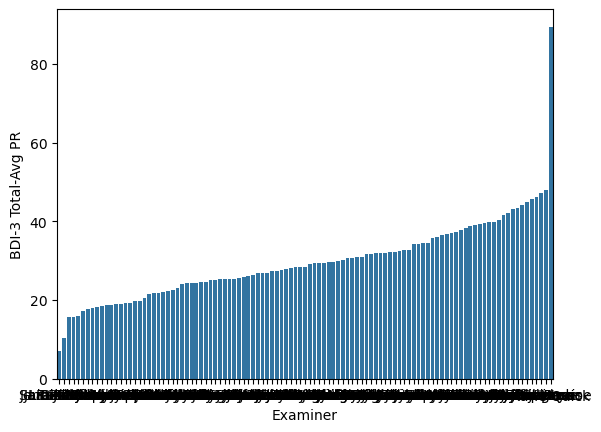

In [36]:
sns.barplot(eda_examiner_total, x="Examiner", y="BDI-3 Total-Avg PR")

In [37]:
eda_examiner['examiner_count'] = eda_examiner['Examiner'].count()
eda_examiner


,Examiner,BDI-3 Total-Avg PR,Adaptive-Avg PR,Social-Emotional-Avg PR,Communication-Avg PR,Motor-Avg PR,Cognitive-Avg PR,examiner_count
0,Abby Spence,44.847516,44.806522,60.335093,28.656832,55.480124,39.577640,105
1,Alexis Linville,25.931909,28.318519,31.950142,16.579202,44.568661,33.968661,105
2,Alice Starnes,30.921012,30.754231,41.034231,24.318147,41.523256,30.538846,105
3,Allison Coontz,24.417597,24.201288,45.263948,16.998712,31.100429,23.914163,105
4,Ally Simmons,25.036213,23.062458,30.230233,20.240199,36.553488,32.529236,105
...,...,...,...,...,...,...,...,...
100,Tiffany Maynard,27.581633,30.620408,41.475510,22.536735,39.202381,24.248299,105
101,Tiffany Treadway,19.094904,18.464968,18.621019,17.087261,37.389809,26.392994,105
102,Toni London,22.684880,23.907560,30.275945,18.160137,34.026460,28.205155,105
103,Tracey Hardiman,34.275248,27.909709,47.221898,22.265770,45.374328,45.256691,105


<Axes: xlabel='examiner_count', ylabel='BDI-3 Total-Avg PR'>

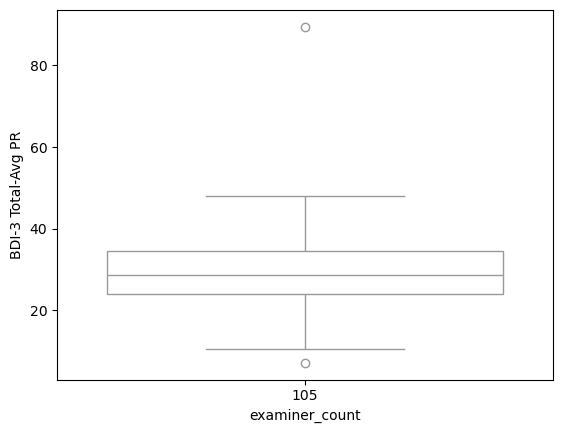

In [38]:
sns.boxplot(data=eda_examiner, x='examiner_count', y='BDI-3 Total-Avg PR',color='#ffffff')

#sns.stripplot(data=eda_examiner, x='examiner_count', y='BDI-3 Total-Avg PR', color='black', alpha=0.5)
#eda_examiner.boxplot(column='BDI-3 Total-Avg PR', by='examiner_count')

In [39]:
q1 = eda_examiner['BDI-3 Total-Avg PR'].quantile(0.25)
q3 = eda_examiner['BDI-3 Total-Avg PR'].quantile(0.75)
iqr = q3 - q1

# 3. Define the outlier thresholds
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# 4. Filter the DataFrame to isolate the outliers
outliers_total = eda_examiner[(eda_examiner['BDI-3 Total-Avg PR'] < lower_bound) | (eda_examiner['BDI-3 Total-Avg PR'] > upper_bound)]
outliers_total[['Examiner','BDI-3 Total-Avg PR']]

,Examiner,BDI-3 Total-Avg PR
54,Karie Quick,89.50
93,Sara Turner,7.05


In [40]:
eda_examiner_melt = eda_examiner.melt(id_vars='Examiner', value_vars = ['BDI-3 Total-Avg PR','Adaptive-Avg PR','Social-Emotional-Avg PR','Communication-Avg PR','Motor-Avg PR','Cognitive-Avg PR'], var_name='Metric')
eda_examiner_melt

,Examiner,Metric,value
0,Abby Spence,BDI-3 Total-Avg PR,44.847516
1,Alexis Linville,BDI-3 Total-Avg PR,25.931909
2,Alice Starnes,BDI-3 Total-Avg PR,30.921012
3,Allison Coontz,BDI-3 Total-Avg PR,24.417597
4,Ally Simmons,BDI-3 Total-Avg PR,25.036213
...,...,...,...
625,Tiffany Maynard,Cognitive-Avg PR,24.248299
626,Tiffany Treadway,Cognitive-Avg PR,26.392994
627,Toni London,Cognitive-Avg PR,28.205155
628,Tracey Hardiman,Cognitive-Avg PR,45.256691


C:\Users\jlmow\AppData\Local\Temp\ipykernel_29040\2933252726.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_examiner_melt, y='Metric', x='value', palette = custom_colors)


<Axes: xlabel='value', ylabel='Metric'>

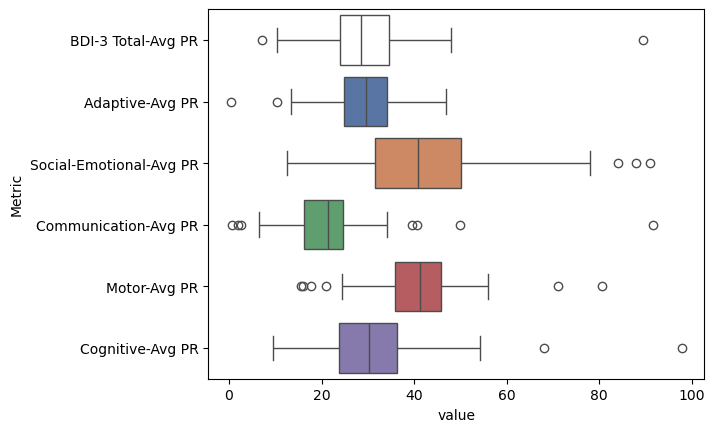

In [41]:
custom_colors = {'BDI-3 Total-Avg PR':'#ffffff','Adaptive-Avg PR': '#4C72B0','Social-Emotional-Avg PR': '#DD8452','Communication-Avg PR': '#55A868','Motor-Avg PR': '#C44E52','Cognitive-Avg PR':'#8172B3'}
	
sns.boxplot(data=eda_examiner_melt, y='Metric', x='value', palette = custom_colors)

## Loop

In [42]:
eda_examiner

,Examiner,BDI-3 Total-Avg PR,Adaptive-Avg PR,Social-Emotional-Avg PR,Communication-Avg PR,Motor-Avg PR,Cognitive-Avg PR,examiner_count
0,Abby Spence,44.847516,44.806522,60.335093,28.656832,55.480124,39.577640,105
1,Alexis Linville,25.931909,28.318519,31.950142,16.579202,44.568661,33.968661,105
2,Alice Starnes,30.921012,30.754231,41.034231,24.318147,41.523256,30.538846,105
3,Allison Coontz,24.417597,24.201288,45.263948,16.998712,31.100429,23.914163,105
4,Ally Simmons,25.036213,23.062458,30.230233,20.240199,36.553488,32.529236,105
...,...,...,...,...,...,...,...,...
100,Tiffany Maynard,27.581633,30.620408,41.475510,22.536735,39.202381,24.248299,105
101,Tiffany Treadway,19.094904,18.464968,18.621019,17.087261,37.389809,26.392994,105
102,Toni London,22.684880,23.907560,30.275945,18.160137,34.026460,28.205155,105
103,Tracey Hardiman,34.275248,27.909709,47.221898,22.265770,45.374328,45.256691,105


In [85]:
#1
outlier_domain = []
#outlier_name = []
#outlier_rank = []

Domains = ['BDI-3 Total','Adaptive', 'Social-Emotional','Communication','Motor','Cognitive']

for dom in Domains:
    q1 = eda_examiner[f'{dom}-Avg PR'].quantile(0.25)
    q3 = eda_examiner[f'{dom}-Avg PR'].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    print(eda_examiner[(eda_examiner[f'{dom}-Avg PR'] < lower_bound) | (eda_examiner[f'{dom}-Avg PR'] > upper_bound)])
    outlier_domain.append(f'{dom}-AVG PR')
    print(outlier_domain)

    #outliers_total[['Examiner','BDI-3 Total-Avg PR']]

#outliers_examiner

# examiner, domain name, outlier value
# Karie Quick, BDI - 3, 89
# karie Quick adaptive avg pr, .4

       Examiner  BDI-3 Total-Avg PR  Adaptive-Avg PR  Social-Emotional-Avg PR  \
54  Karie Quick               89.50             13.5                    91.00   
93  Sara Turner                7.05             18.0                    12.55   

    Communication-Avg PR  Motor-Avg PR  Cognitive-Avg PR  examiner_count  
54                 91.50          80.5              97.8             105  
93                  0.55          15.5               9.5             105  
['BDI-3 Total-AVG PR']
        Examiner  BDI-3 Total-Avg PR  Adaptive-Avg PR  \
18  Bonnie Jones           18.000000          0.40000   
44  Jena Johnson           10.393103         10.47931   

    Social-Emotional-Avg PR  Communication-Avg PR  Motor-Avg PR  \
18                84.000000              2.000000     16.000000   
44                13.772414              6.475862     24.565517   

    Cognitive-Avg PR  examiner_count  
18         68.000000             105  
44         15.937931             105  
['BDI-3 Total-AVG

In [84]:
#6
outlier_domain = []
#outlier_name = []
#outlier_rank = []

#make results dataframe
outlier_results = pd.DataFrame('Examiner','Domain Name','Value')

Domains = ['BDI-3 Total','Adaptive', 'Social-Emotional','Communication','Motor','Cognitive']

for dom in Domains:
    q1 = eda_examiner[f'{dom}-Avg PR'].quantile(0.25)
    q3 = eda_examiner[f'{dom}-Avg PR'].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_df = eda_examiner[(eda_examiner[f'{dom}-Avg PR'] < lower_bound) | (eda_examiner[f'{dom}-Avg PR'] > upper_bound)]
    outlier_results.append('Examiner', f'{dom}-Avg PR', f'{dom}-Avg PR')
                           
#put cell value for eda_examiner[f'{dom}-Avg PR'])

    
    
    #outliers_total[['Examiner','BDI-3 Total-Avg PR']]

#outliers_examiner

# examiner, domain name, outlier value
# Karie Quick, BDI - 3, 89
# karie Quick adaptive avg pr, .4

TypeError: Index(...) must be called with a collection of some kind, 'Domain Name' was passed

In [77]:
#5
outlier_domain = []
#outlier_name = []
#outlier_rank = []

Domains = ['BDI-3 Total','Adaptive', 'Social-Emotional','Communication','Motor','Cognitive']

for dom in Domains:
    q1 = eda_examiner[f'{dom}-Avg PR'].quantile(0.25)
    q3 = eda_examiner[f'{dom}-Avg PR'].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    #outlier_df =
    
    if (eda_examiner[f'{dom}-Avg PR'] < lower_bound) | (eda_examiner[f'{dom}-Avg PR'] > upper_bound):
        print(eda_examiner[['examiner',f'{dom}-Avg PR']])

#def classify(Adaptive):
#    if Adaptive > 50:
#        return 'Above Avg'
#    elif Adaptive == 50:
#        return 'Avg'
#    else:
#        return 'Below Avg'

#eda_trim_filter['Adaptive'] = eda_trim_filter['Adaptive Percentile Rank'].apply(classify)
#eda_trim_filter
    
# examiner, domain name, outlier value
# Karie Quick, BDI - 3, 89
# karie Quick adaptive avg pr, .4

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [44]:
#2
outliers = []

Domains = ['BDI-3 Total','Adaptive', 'Social-Emotional','Communication','Motor','Cognitive']

for dom in Domains:
    q1 = eda_examiner[f'{dom}-Avg PR'].quantile(0.25)
    q3 = eda_examiner[f'{dom}-Avg PR'].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers_examiner = eda_examiner[(eda_examiner[f'{dom}-Avg PR'] < lower_bound) | (eda_examiner[f'{dom}-Avg PR'] > upper_bound)]
    outlier_domain.append(f'{dom}-AVG PR')
    
    #outliers_total[['Examiner','BDI-3 Total-Avg PR']]

outliers_examiner

,Examiner,BDI-3 Total-Avg PR,Adaptive-Avg PR,Social-Emotional-Avg PR,Communication-Avg PR,Motor-Avg PR,Cognitive-Avg PR,examiner_count
18,Bonnie Jones,18.0,0.4,84.0,2.0,16.0,68.0,105
54,Karie Quick,89.5,13.5,91.0,91.5,80.5,97.8,105


In [45]:
#3
outliers = []

Domains = ['BDI-3 Total','Adaptive', 'Social-Emotional','Communication','Motor','Cognitive']

for dom in Domains:
    q1 = eda_examiner[f'{dom}-Avg PR'].quantile(0.25)
    q3 = eda_examiner[f'{dom}-Avg PR'].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers_examiner = eda_examiner[(eda_examiner[f'{dom}-Avg PR'] < lower_bound) | (eda_examiner[f'{dom}-Avg PR'] > upper_bound)]
     
    #outliers_total[['Examiner','BDI-3 Total-Avg PR']]

outliers_examiner

,Examiner,BDI-3 Total-Avg PR,Adaptive-Avg PR,Social-Emotional-Avg PR,Communication-Avg PR,Motor-Avg PR,Cognitive-Avg PR,examiner_count
18,Bonnie Jones,18.0,0.4,84.0,2.0,16.0,68.0,105
54,Karie Quick,89.5,13.5,91.0,91.5,80.5,97.8,105


pr_name =[]
pr_value = []

Domains = ['BDI-3 Total','Adaptive', 'Social-Emotional','Communication','Motor','Cognitive']
for dom in Domains:
    print(f'{dom} AVG PR = {eda[f"{dom} Percentile Rank"].mean()}')
    pr_name.append(f'{dom} AVG PR')
    pr_value.append(eda[f"{dom} Percentile Rank"].mean())

In [46]:
eda_examiner_bin = pd.cut(eda_examiner['BDI-3 Total-Avg PR'], bins=10).value_counts().reset_index()
eda_examiner_bin


,BDI-3 Total-Avg PR,count
0,"(23.54, 31.785]",41
1,"(31.785, 40.03]",26
2,"(15.295, 23.54]",24
3,"(40.03, 48.275]",11
4,"(6.968, 15.295]",2
5,"(81.255, 89.5]",1
6,"(48.275, 56.52]",0
7,"(56.52, 64.765]",0
8,"(64.765, 73.01]",0
9,"(73.01, 81.255]",0


# Q6
6. Is there any difference in scoring noted based on evaluation type?

In [47]:
assessment_bad = eda.groupby('Program Label')[['BDI-3 Total Percentile Rank',
'Adaptive Percentile Rank','Social-Emotional Percentile Rank','Communication Percentile Rank','Motor Percentile Rank',
'Cognitive Percentile Rank']].mean().reset_index()
assessment_bad

,Program Label,BDI-3 Total Percentile Rank,Adaptive Percentile Rank,Social-Emotional Percentile Rank,Communication Percentile Rank,Motor Percentile Rank,Cognitive Percentile Rank
0,BDI-3 Annual Evaluation,26.724172,26.210646,37.855539,19.705526,36.809925,26.474504
1,BDI-3 Eligibility Evaluation,31.533328,32.002390,42.304385,22.670108,44.374047,34.368608
2,BDI-3 Milestone or Exit Evaluation,26.775369,28.335468,38.397537,18.589655,41.541872,22.843350


In [48]:
assessment_bad_melt = assessment_bad.melt(id_vars=['Program Label'],value_vars=['BDI-3 Total Percentile Rank','Adaptive Percentile Rank',	'Social-Emotional Percentile Rank',	'Communication Percentile Rank', 'Motor Percentile Rank','Cognitive Percentile Rank'],var_name='Domain')


<Axes: xlabel='Domain'>

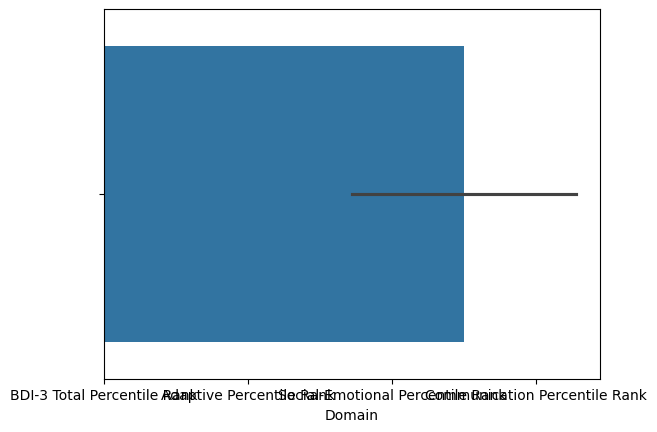

In [49]:
sns.barplot(data=assessment_bad_melt, x='Domain',)


In [50]:
eda_programs = eda.groupby('Child ID')['Program Label'].value_counts().reset_index()#pivot(index='Child ID', columns='Program Label')#.reset_index()
eda_programs

,Child ID,Program Label,count
0,44879,BDI-3 Eligibility Evaluation,1
1,47795,BDI-3 Eligibility Evaluation,1
2,54340,BDI-3 Eligibility Evaluation,1
3,54344,BDI-3 Eligibility Evaluation,1
4,54515,BDI-3 Eligibility Evaluation,1
...,...,...,...
19149,SP03287,BDI-3 Eligibility Evaluation,1
19150,SP03288,BDI-3 Eligibility Evaluation,1
19151,SP03289,BDI-3 Eligibility Evaluation,1
19152,SP03290,BDI-3 Annual Evaluation,1


In [51]:
eda_programs_pvt = eda_programs.pivot_table(index='Child ID', columns='Program Label',values='count').reset_index()
eda_programs_pvt

Program Label,Child ID,BDI-3 Annual Evaluation,BDI-3 Eligibility Evaluation,BDI-3 Milestone or Exit Evaluation
0,44879,NaN,1.0,NaN
1,47795,NaN,1.0,NaN
2,54340,NaN,1.0,NaN
3,54344,NaN,1.0,NaN
4,54515,NaN,1.0,NaN
...,...,...,...,...
18998,SP03287,NaN,1.0,NaN
18999,SP03288,NaN,1.0,NaN
19000,SP03289,NaN,1.0,NaN
19001,SP03290,1.0,NaN,NaN


In [52]:
eda_programs_pvt.dtypes

Program Label
Child ID                               object
BDI-3 Annual Evaluation               float64
BDI-3 Eligibility Evaluation          float64
BDI-3 Milestone or Exit Evaluation    float64
dtype: object

In [53]:
eda_programs_pvt = eda_programs_pvt[(eda_programs_pvt['BDI-3 Eligibility Evaluation'] >0) & (eda_programs_pvt['BDI-3 Annual Evaluation'].notna())]
    

In [54]:
eda_programs_pvt['Elig & Annual'] = 'yes'
eda_programs_pvt

C:\Users\jlmow\AppData\Local\Temp\ipykernel_29040\523322777.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda_programs_pvt['Elig & Annual'] = 'yes'


Program Label,Child ID,BDI-3 Annual Evaluation,BDI-3 Eligibility Evaluation,BDI-3 Milestone or Exit Evaluation,Elig & Annual
217,488572,1.0,1.0,NaN,yes
250,489576,1.0,1.0,NaN,yes
265,490073,1.0,1.0,NaN,yes
279,490333,1.0,1.0,NaN,yes
448,494997,1.0,1.0,NaN,yes
...,...,...,...,...,...
10117,553001,1.0,1.0,NaN,yes
10451,553684,1.0,1.0,NaN,yes
11947,557059,1.0,1.0,NaN,yes
12834,559848,1.0,1.0,NaN,yes


In [55]:
eda_merged = pd.merge(eda, eda_programs_pvt, on='Child ID')
eda_merged

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE,BDI-3 Annual Evaluation,BDI-3 Eligibility Evaluation,BDI-3 Milestone or Exit Evaluation,Elig & Annual
0,488572,F,2020-08-03,Upper Cumberland,contract 2,BDI-3 Eligibility Evaluation,18.0,94.0,34.0,87-101,...,1990-04-01 00:00:00,426.0,408 - 444,– 1.67,33.0,15,1.0,1.0,NaN,yes
1,488572,F,2020-08-03,Upper Cumberland,contract 2,BDI-3 Annual Evaluation,12.0,76.0,5.0,70-84,...,45/90,471.0,459 - 484,– 1.00,40.0,29,1.0,1.0,NaN,yes
2,489576,F,2020-07-08,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,5.0,55.0,0.1,51-65,...,<1/90,378.0,365 - 391,– 3.00,20.0,<1,1.0,1.0,NaN,yes
3,489576,F,2020-07-08,Greater Nashville,contract 2,BDI-3 Annual Evaluation,10.0,70.0,2.0,65-79,...,1990-02-01 00:00:00,437.0,421 - 453,– 1.67,33.0,15,1.0,1.0,NaN,yes
4,490073,M,2020-09-13,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,9.0,67.0,1.0,62-76,...,1990-04-01 00:00:00,426.0,408 - 444,– 1.67,33.0,15,1.0,1.0,NaN,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,559848,F,2021-02-05,South Central,contract 2,BDI-3 Annual Evaluation,23.0,109.0,73.0,101-115,...,68/90,471.0,459 - 484,– 0.67,43.0,36,1.0,1.0,NaN,yes
230,559848,F,2022-03-21,Memphis Delta,contract 3,BDI-3 Eligibility Evaluation,10.0,100.0,50.0,90-110,...,96/90,451.0,429 - 473,0.33,53.0,57,1.0,1.0,NaN,yes
231,562963,M,2023-09-01,First Tennessee,contract 1,BDI-3 Annual Evaluation,14.0,120.0,91.0,107-127,...,98/90,352.0,323 - 381,0.67,57.0,64,2.0,1.0,NaN,yes
232,562963,M,2023-09-01,First Tennessee,contract 1,BDI-3 Annual Evaluation,14.0,120.0,91.0,107-127,...,98/90,352.0,323 - 381,0.67,57.0,64,2.0,1.0,NaN,yes


In [56]:
eda_merged_filter = eda_merged.loc[eda_merged['Elig & Annual']=='yes']

In [98]:
eda_merged_filter_group = eda_merged_filter.groupby('Program Label')[['BDI-3 Total Percentile Rank',
'Adaptive Percentile Rank','Social-Emotional Percentile Rank','Communication Percentile Rank','Motor Percentile Rank',
'Cognitive Percentile Rank']].mean().reset_index()

In [103]:
eda_merged_filter_group_melt = eda_merged_filter_group.melt(id_vars=['Program Label'], var_name='Domain', value_name='Score')
eda_merged_filter_group_melt
#(id_vars=['Student'], var_name='Subject', value_name='Score')
#print("\nReshaped (Long):\n", melted_df)

,Program Label,Domain,Score
0,BDI-3 Annual Evaluation,BDI-3 Total Percentile Rank,22.788034
1,BDI-3 Eligibility Evaluation,BDI-3 Total Percentile Rank,15.575652
2,BDI-3 Annual Evaluation,Adaptive Percentile Rank,25.828205
3,BDI-3 Eligibility Evaluation,Adaptive Percentile Rank,18.680000
4,BDI-3 Annual Evaluation,Social-Emotional Percentile Rank,34.292308
5,BDI-3 Eligibility Evaluation,Social-Emotional Percentile Rank,26.566087
6,BDI-3 Annual Evaluation,Communication Percentile Rank,15.435043
7,BDI-3 Eligibility Evaluation,Communication Percentile Rank,5.426957
8,BDI-3 Annual Evaluation,Motor Percentile Rank,33.125641
9,BDI-3 Eligibility Evaluation,Motor Percentile Rank,36.013043


In [125]:
eda_merged_filter_group_melt['Score'] = eda_merged_filter_group_melt['Score'].round(2)
eda_merged_filter_group_melt

,Program Label,Domain,Score
0,BDI-3 Annual Evaluation,BDI-3 Total Percentile Rank,22.79
1,BDI-3 Eligibility Evaluation,BDI-3 Total Percentile Rank,15.58
2,BDI-3 Annual Evaluation,Adaptive Percentile Rank,25.83
3,BDI-3 Eligibility Evaluation,Adaptive Percentile Rank,18.68
4,BDI-3 Annual Evaluation,Social-Emotional Percentile Rank,34.29
5,BDI-3 Eligibility Evaluation,Social-Emotional Percentile Rank,26.57
6,BDI-3 Annual Evaluation,Communication Percentile Rank,15.44
7,BDI-3 Eligibility Evaluation,Communication Percentile Rank,5.43
8,BDI-3 Annual Evaluation,Motor Percentile Rank,33.13
9,BDI-3 Eligibility Evaluation,Motor Percentile Rank,36.01


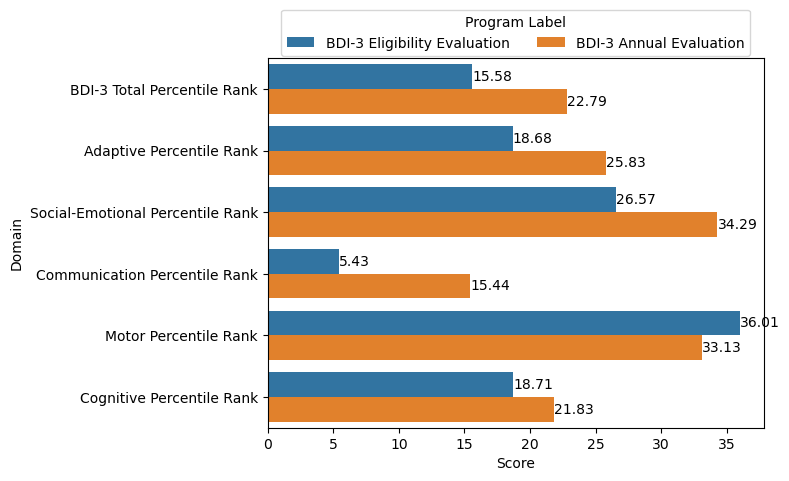

In [126]:
custom_hue_order = ["BDI-3 Eligibility Evaluation","BDI-3 Annual Evaluation"]
ax = sns.barplot(eda_merged_filter_group_melt, hue='Program Label', y='Domain', x='Score', hue_order = custom_hue_order)
ax.bar_label(ax.containers[0], fontsize=10)
ax.bar_label(ax.containers[1], fontsize=10)

sns.move_legend(ax, "upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)

            


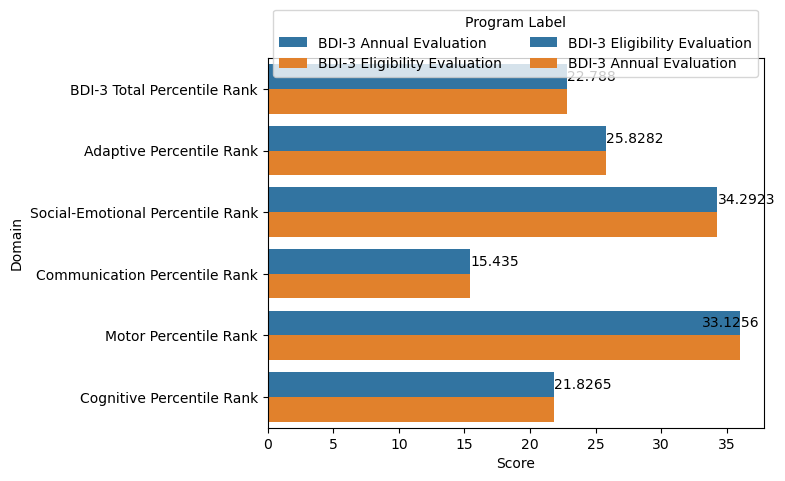

In [120]:

ax = sns.barplot(eda_merged_filter_group_melt, hue='Program Label', y='Domain', x='Score', hue_order = custom_hue_order)
ax.bar_label(ax.containers[0], fontsize=10)

            
#y=[['BDI-3 Total Percentile Rank','Adaptive Percentile Rank', 'Social-Emotional Percentile Rank', 'Communication Percentile Rank', 'Motor Percentile Rank', 'Cognitive Percentile Rank']], )


# Progress from Eligibility to Annual Review

In [58]:
eda_elig = eda.loc[eda['Program Label'] == 'BDI-3 Eligibility Evaluation']
eda_annual = eda.loc[eda['Program Label'] == 'BDI-3 Annual Evaluation']
eda_exit = eda.loc[eda['Program Label'] == 'BDI-3 Milestone or Exit Evaluation']

In [59]:
eda_elig_filter = eda_elig.sort_values('Adaptive-Self Care Date of Testing').drop_duplicates(subset=['Child ID','Adaptive-Self Care Date of Testing'],keep='first')

In [60]:
eda_annual_filter = eda_annual.sort_values('Adaptive-Self Care Date of Testing').drop_duplicates(subset=['Child ID','Adaptive-Self Care Date of Testing'],keep='first')

In [61]:
eda_exit_filter = eda_exit.sort_values('Adaptive-Self Care Date of Testing').drop_duplicates(subset=['Child ID','Adaptive-Self Care Date of Testing'],keep='first')

In [62]:
eda_elig_filter['keep'] = 'yes'
eda_elig_filter.head()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE,keep
10278,540677,M,2022-05-09,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,9.0,95.0,37.0,86-106,...,12.0,75,8,98/90,395.0,376 - 415,0.67,57.0,64,yes
460,489576,F,2020-07-08,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,5.0,55.0,0.1,51-65,...,1.0,<1,6,<1/90,378.0,365 - 391,– 3.00,20.0,<1,yes
10524,542205,M,2021-05-10,Greater Nashville,contract 2,BDI-3 Eligibility Evaluation,11.0,105.0,63.0,94-114,...,8.0,25,15,66/90,426.0,408 - 444,– 0.67,43.0,36,yes
10461,541881,F,2022-11-07,Southwest,contract 3,BDI-3 Eligibility Evaluation,9.0,95.0,37.0,86-106,...,8.0,25,<0,27/90,312.0,287 - 337,– 0.67,43.0,36,yes
10444,541736,F,2021-07-12,Southeast Tennessee,contract 1,BDI-3 Eligibility Evaluation,11.0,105.0,63.0,94-114,...,16.0,98,28,>99/90,471.0,459 - 484,2,70.0,92,yes


In [63]:
eda_annual_filter['keep'] = 'yes'
eda_annual_filter.head()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE,keep
185,484384,M,2020-06-02,First Tennessee,contract 1,BDI-3 Annual Evaluation,6.0,58.0,0.3,54-68,...,4.0,2,15,1990-02-01 00:00:00,426.0,408 - 444,– 2.00,30.0,8,yes
4851,524748,F,2020-03-06,Upper Cumberland,contract 2,BDI-3 Annual Evaluation,7.0,61.0,1.0,56-70,...,1.0,<1,8,<1/90,395.0,376 - 415,– 3.00,20.0,<1,yes
1301,500216,F,2020-08-05,Upper Cumberland,contract 2,BDI-3 Annual Evaluation,17.0,91.0,27.0,85-99,...,8.0,25,25,50/90,464.0,450 - 479,– 0.67,43.0,36,yes
3943,521024,F,2021-11-01,Upper Cumberland,contract 2,BDI-3 Annual Evaluation,5.0,75.0,5.0,68-88,...,10.0,50,15,88/90,426.0,408 - 444,0,50.0,50,yes
4241,522758,M,2020-03-10,Northwest,contract 3,BDI-3 Annual Evaluation,11.0,73.0,4.0,68-82,...,6.0,9,22,1990-08-01 00:00:00,451.0,429 - 473,– 1.33,37.0,22,yes


In [64]:
eda_exit_filter['keep'] = 'yes'
eda_exit_filter.head()

,Child ID,Gender,Date of Birth,Location - Sub Level 1,contract number,Program Label,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,...,Cognitive-Perception and Concepts SS,Cognitive-Perception and Concepts PR,Cognitive-Perception and Concepts AE,Cognitive-Perception and Concepts RDI,Cognitive-Perception and Concepts CSS,Cognitive-Perception and Concepts CSS 90%,Cognitive-Perception and Concepts Z-Score,Cognitive-Perception and Concepts T-Score,Cognitive-Perception and Concepts NCE,keep
1933,504737,M,2020-03-03,Upper Cumberland,contract 2,BDI-3 Milestone or Exit Evaluation,8.0,64.0,1.0,59-73,...,7.0,16,25,27/90,464.0,450 - 479,– 1.00,40.0,29,yes
210,485226,M,2020-02-26,Northwest,contract 3,BDI-3 Milestone or Exit Evaluation,18.0,94.0,34.0,87-101,...,9.0,37,31,73/90,482.0,471 - 493,– 0.33,47.0,43,yes
2911,511521,M,2020-03-11,Upper Cumberland,contract 2,BDI-3 Milestone or Exit Evaluation,15.0,85.0,16.0,79-93,...,7.0,16,25,27/90,464.0,450 - 479,– 1.00,40.0,29,yes
3326,514341,M,2020-02-21,Greater Nashville,contract 2,BDI-3 Milestone or Exit Evaluation,13.0,79.0,8.0,73-87,...,1.0,<1,12,<1/90,411.0,392 - 431,– 3.00,20.0,<1,yes
10167,539977,M,2020-04-18,Upper Cumberland,contract 2,BDI-3 Milestone or Exit Evaluation,13.0,79.0,8.0,73-87,...,3.0,1,15,1990-01-01 00:00:00,426.0,408 - 444,– 2.33,27.0,1,yes


In [65]:
eda_pivot1 = eda.pivot(index='Child ID', columns='Program Label', values='Adaptive-Self Care Date of Testing')
print(eda_pivot1)

ValueError: Index contains duplicate entries, cannot reshape

In [ ]:
eda_pivot2 = eda.pivot(index='Child ID', columns='Program Label', values='Adaptive-Self Care Date of Testing')
print(eda_pivot2)


#pivoted_df = df.pivot(index='Date', columns='City', values='Temperature')
#print(pivoted_df)


3. Is there a pattern of significant differences in children's scores in the sub-domains within a domain? For example, a gap between a child's expressive (talking) and receptive (understanding) language scores may indicate that additional evaluation is needed for that child's eligibility. A gap between these sub-domains for all or most children may indicate the BDI-3 tool may lack sensitivity in the language domain.

4. Does the child's age seem to impact their scoring?

5. Eligibility is currently based on domains. A child would be considered eligible based on a 40% delay in one area or 25% delay in two areas, as determined by Development Quotient (DQ) scores. A DQ of 70 or less indicates a 40% delay, and a DQ between 71 and 78 indicates a 25% delay. If TEIS added an option for eligibility based on the total score on the BDI-3 total score (DQ score of 70 or less), are there any children who would have qualified that did not qualify based on the current method?

6. Is there any difference in scoring noted based on evaluation type?

7. Is there any notable pattern of scoring by region? Note: TEIS contracts with three agencies for evaluations (one per grand region) as follows:  
* East TN, First TN and Southeast
* Greater Nashville, Upper Cumberland, and South Central
* Northwest, Southwest, and Memphis Delta


Stretch Goal:
* Investigate the records that are missing ID values. Have they gotten better or worse over time? Are there repeat offenders?
* As noted above, this evaluation may be repeated every 4 months. How often did it occur that a child was assessed multiple times in a time period of less than 120 days. Has this gotten better or worse over time?

